Installing libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

Loading the dataset

In [17]:
df = pd.read_csv("../datasets/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

# Create new columns
df["instruction_length"] = df["instruction"].apply(lambda x: len(str(x).split()))
df["response_length"] = df["response"].apply(lambda x: len(str(x).split()))

# Preview
df.head()

,flags,instruction,category,intent,response,instruction_length,response_length
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...,6,37
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...,9,48
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...,7,205
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...,7,166
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...,9,191


Intent Distribution

C:\Users\Kids-PC\AppData\Local\Temp\ipykernel_15784\72276690.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="intent", order=df["intent"].value_counts().index, palette="Set2")


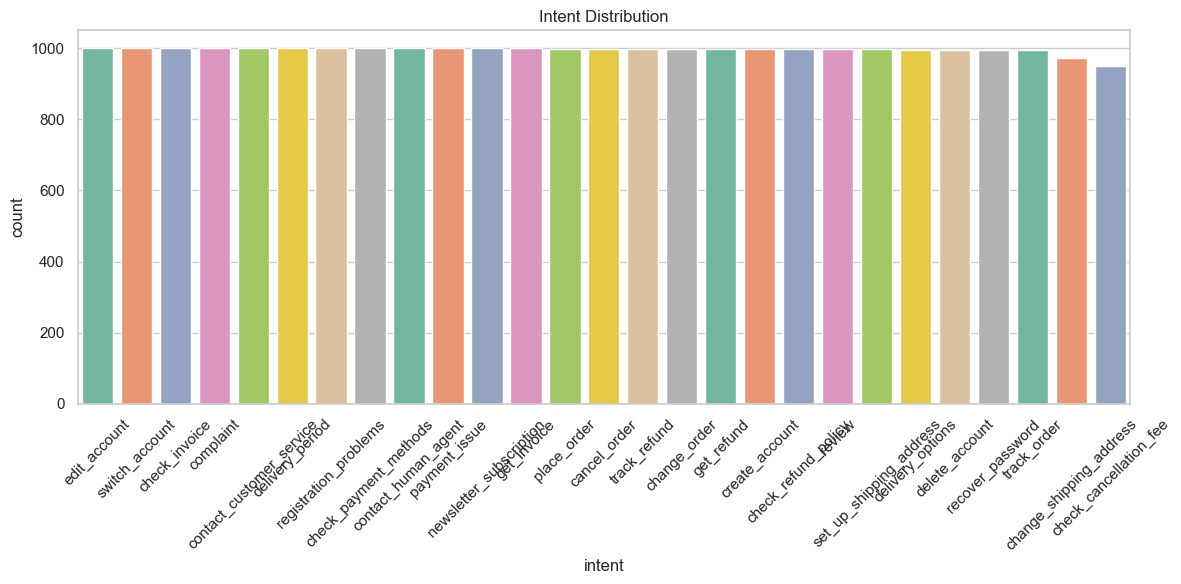

In [18]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="intent", order=df["intent"].value_counts().index, palette="Set2")
plt.title("Intent Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Instruction length distribution

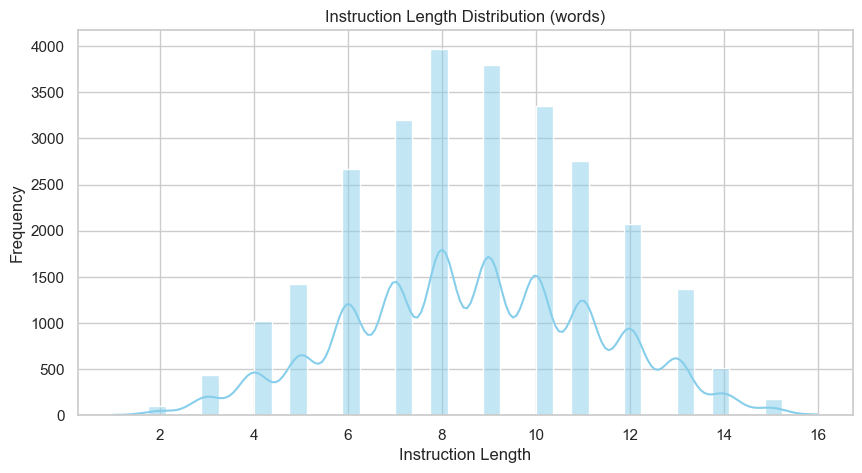

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(df["instruction_length"], bins=40, color="skyblue", kde=True)
plt.title("Instruction Length Distribution (words)")
plt.xlabel("Instruction Length")
plt.ylabel("Frequency")
plt.show()

Response length distribution

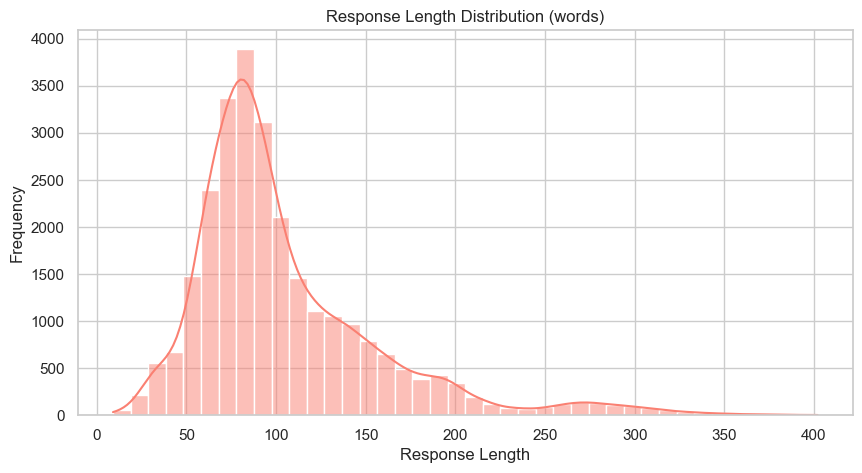

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df["response_length"], bins=40, color="salmon", kde=True)
plt.title("Response Length Distribution (words)")
plt.xlabel("Response Length")
plt.ylabel("Frequency")
plt.show()

Top 10 intents

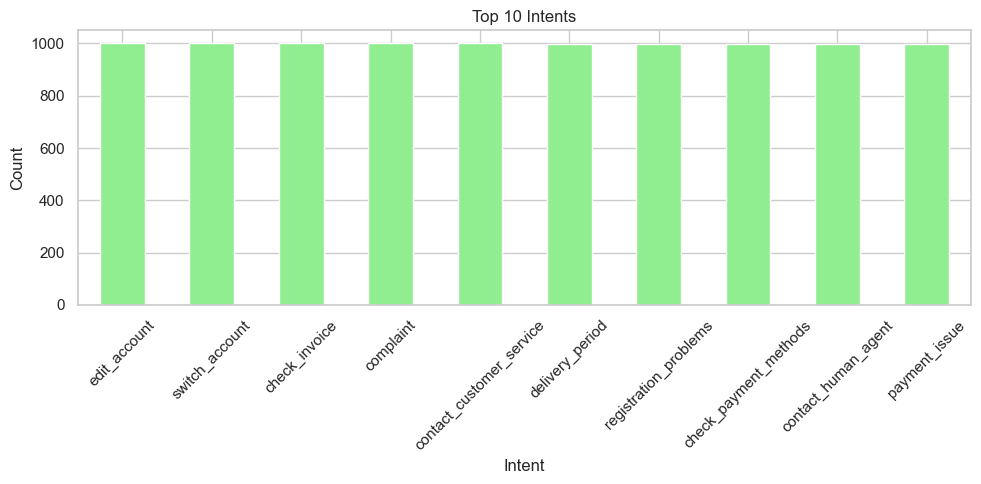

In [21]:
df["intent"].value_counts().nlargest(10).plot(kind="bar", color="lightgreen")
plt.title("Top 10 Intents")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Duplicate instruction-response pairs

In [22]:
dupes = df.duplicated(subset=["instruction", "response"])
print(f"Duplicate instruction-response pairs: {dupes.sum()} / {len(df)}")

Duplicate instruction-response pairs: 0 / 26872


Instruction-Response length correlation

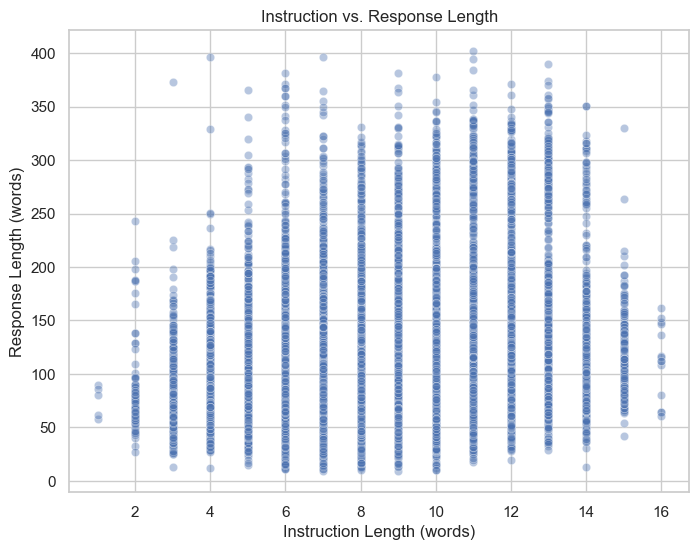

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="instruction_length", y="response_length", data=df, alpha=0.4)
plt.title("Instruction vs. Response Length")
plt.xlabel("Instruction Length (words)")
plt.ylabel("Response Length (words)")
plt.show()